Exploration & Analysis

# Credit Score Classification — Model Deployment
## Tahap 1: Eksplorasi Data & Pemodelan (Notebook)
Dataset: data_A | Target: Credit_Score (Good / Standard / Poor) | 25.000 baris

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # biar semua kolom kelihatan
sns.set_style("whitegrid")

### 1. Load Data
Memuat dataset dengan `index_col=0` karena kolom pertama hanya nomor urut, bukan fitur.
Data terdiri dari 25.000 baris dan 28 kolom.

In [21]:
df = pd.read_csv("data_A.csv", index_col=0)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.0,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.0,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.0,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.0,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.0,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [22]:
print("Shape:", df.shape)
print("\nDistribusi target:")
print(df['Credit_Score'].value_counts())
df.info()

Shape: (25000, 28)

Distribusi target:
Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  str    
 1   Customer_ID               25000 non-null  str    
 2   Month                     25000 non-null  str    
 3   Name                      22440 non-null  str    
 4   Age                       25000 non-null  str    
 5   SSN                       25000 non-null  str    
 6   Occupation                25000 non-null  str    
 7   Annual_Income             25000 non-null  str    
 8   Monthly_Inhand_Salary     21417 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25000 non-null  int64  


### 2. Data Cleaning
Membersihkan data mentah agar siap dipakai model. Lima masalah yang ditangani:

1. **Buang kolom identitas** (`ID`, `Customer_ID`, `Name`, `SSN`) — tidak prediktif dan berisiko menyebabkan *data leakage*.
2. **Angka kotor** — beberapa kolom numerik mengandung karakter `_` (mis. `"3_"`), sehingga terbaca sebagai teks. Dibersihkan lalu dikonversi ke angka.
3. **Nilai mustahil** — mis. umur -500 atau 8698 tahun; nilai di luar batas wajar diubah menjadi NaN.
4. **Placeholder palsu** — nilai seperti `"_______"`, `"_"`, `"NM"` sebenarnya adalah data hilang, diubah menjadi NaN.
5. **Parsing format** — `Credit_History_Age` ("20 Years and 5 Months") dikonversi ke total bulan.

Hasil: 28 → 24 kolom, tipe data sudah benar. Nilai NaN sengaja **belum diisi** dan akan diimputasi di dalam pipeline untuk mencegah *data leakage*.

In [23]:
import re

def clean_data(df):
    """
    Membersihkan dataset credit score.
    Menangani: kolom identitas, angka kotor, nilai mustahil,
    placeholder palsu, dan format teks.
    """
    df = df.copy()  # jangan ubah data asli, kerjakan di salinan

    # --- 1. Buang kolom identitas (tidak prediktif + mencegah leakage) ---
    df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

    # --- 2. Angka yang ketempelan '_' -> ubah jadi angka beneran ---
    kolom_angka = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                   'Changed_Credit_Limit', 'Outstanding_Debt',
                   'Amount_invested_monthly', 'Monthly_Balance']
    for c in kolom_angka:
        df[c] = (df[c].astype(str)
                      .str.replace('_', '', regex=False)   # hapus underscore
                      .str.strip()                          # hapus spasi
                      .replace({'': np.nan, 'nan': np.nan})) # teks kosong -> NaN
        df[c] = pd.to_numeric(df[c], errors='coerce')       # teks -> angka

    # --- 3. Nilai mustahil -> NaN (akan diisi nanti di pipeline) ---
    df.loc[(df['Age'] < 14) | (df['Age'] > 100), 'Age'] = np.nan
    df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
    df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
    df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan
    df.loc[df['Num_Credit_Card'] > 15, 'Num_Credit_Card'] = np.nan
    df.loc[df['Interest_Rate'] > 50, 'Interest_Rate'] = np.nan
    df.loc[df['Num_Credit_Inquiries'] > 30, 'Num_Credit_Inquiries'] = np.nan

    # --- 4. Placeholder palsu (sebenarnya = data hilang) -> NaN ---
    df['Occupation'] = df['Occupation'].replace('_______', np.nan)
    df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

    # --- 5. "20 Years and 5 Months" -> total bulan (245) ---
    def ke_bulan(s):
        if pd.isna(s):
            return np.nan
        tahun = re.search(r'(\d+)\s*Year', str(s))
        bulan = re.search(r'(\d+)\s*Month', str(s))
        y = int(tahun.group(1)) if tahun else 0
        m = int(bulan.group(1)) if bulan else 0
        return y * 12 + m
    df['Credit_History_Age'] = df['Credit_History_Age'].apply(ke_bulan)

    return df

### Fungsi `clean_data()`

Seluruh proses pembersihan dirangkum dalam satu fungsi agar dapat digunakan kembali secara konsisten pada data train, test, maupun data baru saat *deployment*. Fungsi ini menerima sebuah DataFrame dan mengembalikan versi yang sudah bersih, menangani lima jenis masalah:

1. **Membuang kolom identitas** (`ID`, `Customer_ID`, `Name`, `SSN`) yang tidak prediktif dan berisiko menyebabkan *data leakage*.
2. **Mengonversi angka kotor** — menghapus karakter `_` lalu mengubah teks menjadi tipe numerik.
3. **Menangani nilai mustahil** — nilai di luar batas wajar (mis. umur < 14 atau > 100) diubah menjadi NaN.
4. **Mengganti placeholder palsu** (`"_______"`, `"_"`, `"NM"`) menjadi NaN karena sebenarnya merupakan data hilang.
5. **Parsing format teks** — `Credit_History_Age` dikonversi dari format kalimat menjadi total bulan.

Penggunaan fungsi (bukan kode berulang) dipilih agar pembersihan cukup ditulis satu kali namun dapat dipanggil berkali-kali, mudah dirawat, dan siap diubah menjadi *class* `Preprocessor` pada tahap pipeline (poin 1b).

In [24]:
df_clean = clean_data(df)

print("Shape sesudah cleaning:", df_clean.shape)   # harusnya (25000, 24)
print("\nTipe data per kolom:")
print(df_clean.dtypes)
print("\nSisa nilai kosong (NaN):")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Shape sesudah cleaning: (25000, 24)

Tipe data per kolom:
Month                           str
Age                         float64
Occupation                      str
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Type_of_Loan                    str
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour               str
Monthly_Balance             float64
Credit_Score                    str
dtype: object

Sisa nilai kosong (NaN):
Age                         666
Occupa

### 3. Exploratory Data Analysis (EDA)
Menganalisis pola data secara visual untuk mendasari keputusan pemodelan.
Empat analisis: distribusi target, fitur numerik vs target, fitur kategorikal vs target, dan korelasi antar fitur.

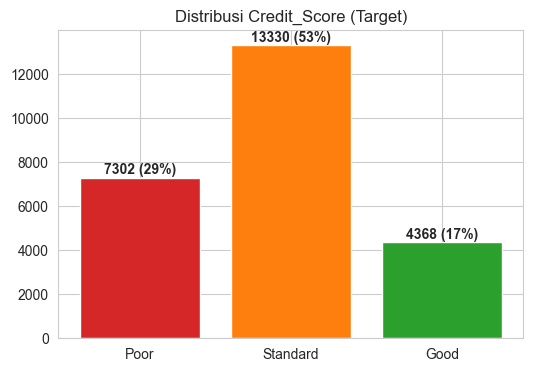

In [25]:
order = ['Poor', 'Standard', 'Good']
pal = {'Poor':'#d62728', 'Standard':'#ff7f0e', 'Good':'#2ca02c'}

fig, ax = plt.subplots(figsize=(6,4))
vc = df_clean['Credit_Score'].value_counts().reindex(order)
ax.bar(vc.index, vc.values, color=[pal[x] for x in order])
for i, v in enumerate(vc.values):
    ax.text(i, v+150, f"{v} ({v/len(df_clean)*100:.0f}%)", ha='center', fontweight='bold')
ax.set_title('Distribusi Credit_Score (Target)')
plt.show()

Distribusi Variabel Target (Credit_Score)
Pada langkah ini saya memeriksa sebaran kelas pada variabel target. Tujuannya untuk mengetahui apakah jumlah data tiap kelas seimbang, karena hal ini menentukan pemilihan metrik evaluasi.
Hasil menunjukkan distribusi yang tidak seimbang (imbalanced): kelas Standard mendominasi (~53%), diikuti Poor (~29%), sedangkan Good hanya ~17%. Karena ketidakseimbangan ini, akurasi (accuracy) bukan metrik yang tepat — model yang selalu menebak "Standard" sudah mendapat akurasi 53% tanpa benar-benar belajar. Oleh karena itu metrik utama yang digunakan adalah Macro F1-Score, yang memberi bobot setara pada setiap kelas termasuk kelas minoritas.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27728\3052171444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='Credit_Score', y=c, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27728\3052171444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='Credit_Score', y=c, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27728\3052171444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='Credit_Score', y=c, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27728\3052171444.py:5: Futur

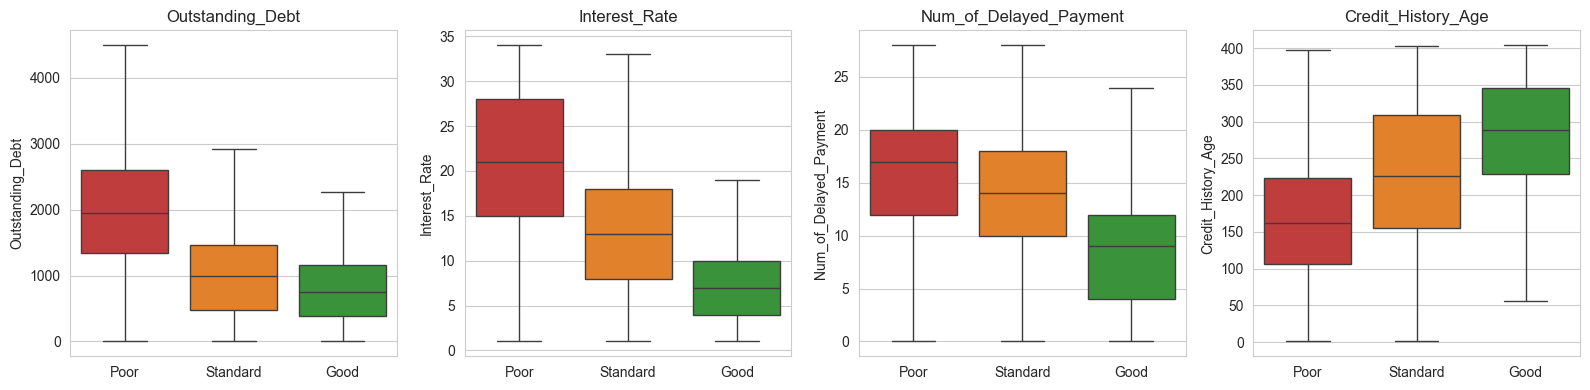

In [26]:
key = ['Outstanding_Debt', 'Interest_Rate', 'Num_of_Delayed_Payment', 'Credit_History_Age']
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, c in zip(axes, key):
    d = df_clean[[c, 'Credit_Score']].dropna()
    sns.boxplot(data=d, x='Credit_Score', y=c, order=order,
                palette=pal, ax=ax, showfliers=False)
    ax.set_title(c)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

Hubungan Fitur Numerik Kunci dengan Target
Saya membandingkan sebaran empat fitur numerik penting (Outstanding_Debt, Interest_Rate, Num_of_Delayed_Payment, Credit_History_Age) terhadap tiap kelas Credit_Score menggunakan boxplot. Tujuannya untuk melihat apakah fitur-fitur ini mampu membedakan antar kelas.
Hasil menunjukkan separasi yang jelas dan konsisten dengan logika finansial: nasabah berkategori Poor memiliki total utang, suku bunga, dan jumlah keterlambatan pembayaran yang lebih tinggi, namun riwayat kredit yang lebih pendek. Sebaliknya kategori Good menunjukkan pola berkebalikan. Karena kotak (boxplot) antar kelas relatif terpisah, keempat fitur ini diprediksi memiliki daya prediksi yang kuat dan kemungkinan akan menjadi fitur terpenting dalam model.

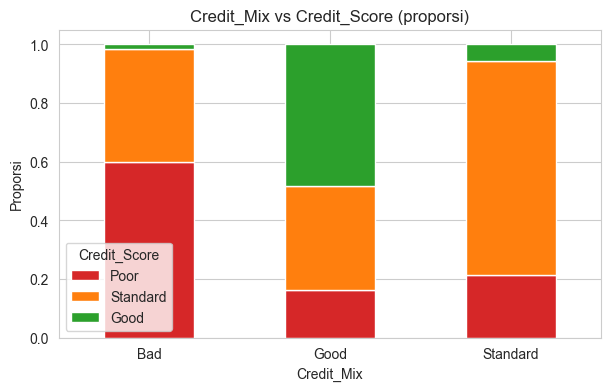

In [27]:
fig, ax = plt.subplots(figsize=(7,4))
ct = pd.crosstab(df_clean['Credit_Mix'], df_clean['Credit_Score'], normalize='index')[order]
ct.plot(kind='bar', stacked=True, color=[pal[x] for x in order], ax=ax)
ax.set_title('Credit_Mix vs Credit_Score (proporsi)')
ax.set_ylabel('Proporsi')
plt.xticks(rotation=0)
plt.show()

Hubungan Fitur Kategorikal (Credit_Mix) dengan Target
Saya memeriksa proporsi tiap kelas Credit_Score di dalam setiap kategori Credit_Mix menggunakan stacked bar chart ternormalisasi. Tujuannya untuk menilai apakah fitur kategorikal juga informatif.
Hasil menunjukkan keterkaitan yang kuat: kategori Credit_Mix = "Bad" didominasi oleh nasabah Poor, sedangkan "Good" didominasi Standard dan Good. Ini membuktikan Credit_Mix adalah fitur kategorikal yang sangat prediktif, sehingga perlu di-encode (diubah ke bentuk numerik) dengan benar agar dapat digunakan model.

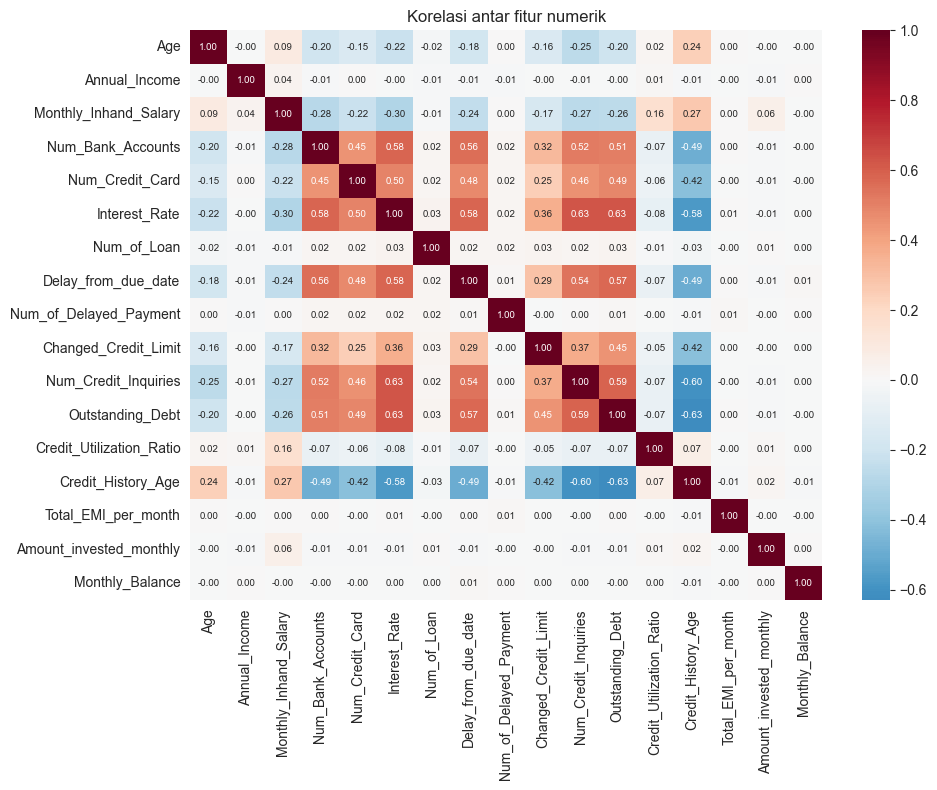

In [28]:
num_cols = df_clean.select_dtypes(include='number').columns
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, annot_kws={'size':7}, ax=ax)
ax.set_title('Korelasi antar fitur numerik')
plt.tight_layout()
plt.show()

Analisis Korelasi Antar Fitur Numerik
Saya menghitung matriks korelasi antar fitur numerik dan memvisualisasikannya dalam heatmap. Tujuannya untuk mendeteksi multikolinearitas — kondisi ketika dua fitur sangat mirip sehingga salah satunya menjadi redundan.
Hasil menunjukkan mayoritas nilai korelasi mendekati 0 (warna pucat), yang berarti tidak ada multikolinearitas yang parah antar fitur. Dengan demikian, tidak ada fitur yang perlu dibuang karena redundansi, dan seluruh fitur numerik dapat dipertahankan untuk tahap pemodelan.

### Ringkasan Temuan EDA & Implikasinya

| No | Temuan EDA | Implikasi terhadap Pemodelan |
|:--:|------------|------------------------------|
| 1 | Target tidak seimbang — *Good* hanya 17%, *Standard* 53% | Metrik utama **Macro F1** (bukan accuracy); gunakan `class_weight='balanced'` |
| 2 | 4 fitur numerik (`Outstanding_Debt`, `Interest_Rate`, `Num_of_Delayed_Payment`, `Credit_History_Age`) memisah jelas antar kelas | Menjadi prediktor utama; model berbasis pohon (tree) cocok |
| 3 | `Credit_Mix` sangat prediktif terhadap target | Lakukan *encoding* kategorikal dengan benar |
| 4 | Korelasi antar fitur numerik rendah | Tidak ada multikolinearitas; semua fitur dipertahankan |
| 5 | Masih terdapat nilai kosong (NaN) | Imputasi dilakukan **di dalam pipeline** untuk mencegah *data leakage* |

## 4. Pemodelan Machine Learning

Setelah data bersih dan pola penting dipahami dari EDA, tahap ini membangun model klasifikasi `Credit_Score` (Good / Standard / Poor). Alur pemodelan:

1. **Pemilihan fitur** — menentukan prediktor dan target.
2. **Train-test split** — memisah data latih & uji secara *stratified*.
3. **Preprocessing pipeline** — imputasi + scaling + encoding di dalam pipeline (anti *data leakage*).
4. **Eksperimen** — membandingkan beberapa algoritma, validasi silang, lalu *hyperparameter tuning* model terbaik.
5. **Evaluasi final & penyimpanan artefak** untuk deployment.

### 4.1 Fitur yang Digunakan

Target: **`Credit_Score`** (3 kelas). Fitur dibagi dua kelompok:

- **Numerik** — pendapatan, gaji bulanan, jumlah rekening/kartu, suku bunga, jumlah & keterlambatan pembayaran, utang, rasio utilisasi kredit, usia riwayat kredit, dll. Mayoritas terbukti memisahkan kelas pada EDA.
- **Kategorikal** — `Month`, `Occupation`, `Credit_Mix`, `Payment_of_Min_Amount`, `Payment_Behaviour`.

Kolom **`Type_of_Loan`** dibuang karena berupa teks bebas multi-nilai (kombinasi banyak jenis pinjaman) yang sulit di-*encode*, dan informasinya sudah terwakili `Num_of_Loan`. Kolom identitas (`ID`, `Customer_ID`, `Name`, `SSN`) sudah dibuang saat cleaning untuk mencegah *data leakage*.

In [29]:
from sklearn.preprocessing import LabelEncoder

# Target dan fitur (buang target + Type_of_Loan yang berupa teks bebas multi-nilai)
X = df_clean.drop(columns=['Credit_Score', 'Type_of_Loan'])
y_raw = df_clean['Credit_Score']

# Encode target: Good/Poor/Standard -> 0/1/2
le = LabelEncoder()
y = le.fit_transform(y_raw)
target_map = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

print("Jumlah fitur :", X.shape[1])
print(f"  - Numerik ({len(num_cols)}):", num_cols)
print(f"  - Kategorikal ({len(cat_cols)}):", cat_cols)
print("\nMapping target:", target_map)

Jumlah fitur : 22
  - Numerik (17): ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
  - Kategorikal (5): ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

Mapping target: {'Good': 0, 'Poor': 1, 'Standard': 2}


### 4.2 Train-Test Split

Data dibagi **80% latih** dan **20% uji**. Pembagian *stratified* menjaga proporsi ketiga kelas tetap sama di kedua subset — penting karena target tidak seimbang. `random_state=42` agar hasil dapat direproduksi.

In [30]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_tr.shape, "| Test:", X_te.shape)
print("Proporsi kelas train:", np.round(np.bincount(y_tr) / len(y_tr), 3))
print("Proporsi kelas test :", np.round(np.bincount(y_te) / len(y_te), 3))

Train: (20000, 22) | Test: (5000, 22)
Proporsi kelas train: [0.175 0.292 0.533]
Proporsi kelas test : [0.175 0.292 0.533]


### 4.3 Preprocessing Pipeline

Seluruh transformasi dibungkus `ColumnTransformer` agar konsisten dan **bebas *data leakage*** — statistik imputasi/scaling hanya dipelajari dari data latih lalu diterapkan ke data uji.

- **Jalur numerik:** imputasi *median* (tahan outlier) → `StandardScaler` (samakan skala, dibutuhkan Logistic Regression).
- **Jalur kategorikal:** imputasi *modus* → `OneHotEncoder` (`handle_unknown='ignore'` agar aman terhadap kategori baru saat deployment).

Pipeline preprocessing ini digabung dengan model sehingga `fit`/`predict` cukup dipanggil pada data (hasil cleaning).

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])
prep = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])
prep

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 4.4 Eksperimen 1 — Perbandingan Beberapa Model (Baseline)

Sesuai arahan soal, setiap proses training mencoba **beberapa algoritma** sekaligus. Empat model dengan karakter berbeda dibandingkan sebagai baseline (parameter default, tanpa tuning):

| Model | Karakter |
|-------|----------|
| Logistic Regression | linear, cepat, baseline |
| Decision Tree | non-linear, mudah ditafsir |
| Random Forest | ensemble *bagging*, kuat & stabil |
| XGBoost | ensemble *boosting*, sering unggul di data tabular |

Model yang mendukung `class_weight='balanced'` diberi bobot kelas untuk menangani ketidakseimbangan. Karena target *imbalanced*, **metrik utama = Macro F1** (rata-rata F1 tiap kelas dengan bobot sama), didampingi Accuracy dan Weighted F1 sebagai pembanding.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                            random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42,
                             eval_metric='mlogloss', n_jobs=-1),
}

hasil = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    hasil.append({
        'Model': name,
        'Accuracy': accuracy_score(y_te, pred),
        'Macro F1': f1_score(y_te, pred, average='macro'),
        'Weighted F1': f1_score(y_te, pred, average='weighted'),
        'Waktu (s)': round(time.time() - t0, 1),
    })

hasil_df = (pd.DataFrame(hasil)
              .sort_values('Macro F1', ascending=False)
              .reset_index(drop=True))
hasil_df.round(4)

,Model,Accuracy,Macro F1,Weighted F1,Waktu (s)
0,Random Forest,0.7396,0.7139,0.7387,1.3
1,XGBoost,0.7298,0.7035,0.7284,1.4
2,Logistic Regression,0.6502,0.6412,0.6550,0.4
3,Decision Tree,0.6294,0.5971,0.6297,0.5


**Interpretasi.** Model berbasis *ensemble* pohon (**Random Forest** dan **XGBoost**) memberi Macro F1 tertinggi, jauh di atas Logistic Regression (linear) dan Decision Tree tunggal. Ini konsisten dengan EDA: hubungan fitur-target bersifat non-linear dan banyak fitur numerik yang *tree-friendly*. **Random Forest** dipilih sebagai kandidat utama untuk divalidasi silang dan di-*tuning*.

### 4.5 Eksperimen 2 — Validasi Silang (Cross-Validation)

Untuk memastikan performa bukan kebetulan dari satu split, dua kandidat terbaik (Random Forest & XGBoost) diuji dengan **Stratified 5-Fold Cross-Validation** pada data latih. Skor Macro F1 yang stabil antar-fold menandakan model robust dan tidak *overfit* ke satu pembagian data.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name in ['Random Forest', 'XGBoost']:
    pipe = Pipeline([('prep', prep), ('model', models[name])])
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    print(f"{name:18s} Macro F1 = {scores.mean():.4f} +/- {scores.std():.4f}   per-fold: {np.round(scores, 4)}")

Random Forest      Macro F1 = 0.6853 +/- 0.0072   per-fold: [0.6888 0.6879 0.6754 0.6787 0.6954]
XGBoost            Macro F1 = 0.6871 +/- 0.0098   per-fold: [0.6809 0.705  0.687  0.6761 0.6866]


**Interpretasi.** Skor antar-fold konsisten dengan deviasi standar kecil, mengonfirmasi bahwa Random Forest stabil dan layak menjadi model final setelah *tuning*.

### 4.6 Eksperimen 3 — Hyperparameter Tuning

Random Forest di-*tuning* dengan `RandomizedSearchCV` (8 kombinasi acak, 3-fold, dioptimalkan untuk **Macro F1**) untuk mencari kombinasi `n_estimators`, `max_depth`, `min_samples_leaf`, dan `max_features` terbaik.

In [34]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipe = Pipeline([
    ('prep', prep),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

param_dist = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [None, 15, 25, 35],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    rf_pipe, param_dist, n_iter=8, scoring='f1_macro',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_tr, y_tr)

print("\nBest params:", search.best_params_)
print(f"Best CV Macro F1: {search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV Macro F1: 0.6911


**Interpretasi.** Kombinasi parameter terbaik dari pencarian dijadikan model final. *Tuning* menyetel kedalaman pohon dan jumlah estimator agar generalisasi optimal pada data uji.

### 4.7 Evaluasi Final pada Data Uji

Model terbaik (Random Forest hasil *tuning*) dievaluasi pada data uji yang belum pernah dilihat, menggunakan **classification report** (precision / recall / F1 per kelas) dan **confusion matrix**.

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = search.best_estimator_
y_pred = best_model.predict(X_te)

print("Macro F1 (test):", round(f1_score(y_te, y_pred, average='macro'), 4))
print("Accuracy (test):", round(accuracy_score(y_te, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_te, y_pred, target_names=le.classes_))

Macro F1 (test): 0.7129
Accuracy (test): 0.7298

Classification Report:

              precision    recall  f1-score   support

        Good       0.58      0.72      0.64       874
        Poor       0.73      0.75      0.74      1460
    Standard       0.80      0.72      0.76      2666

    accuracy                           0.73      5000
   macro avg       0.70      0.73      0.71      5000
weighted avg       0.74      0.73      0.73      5000



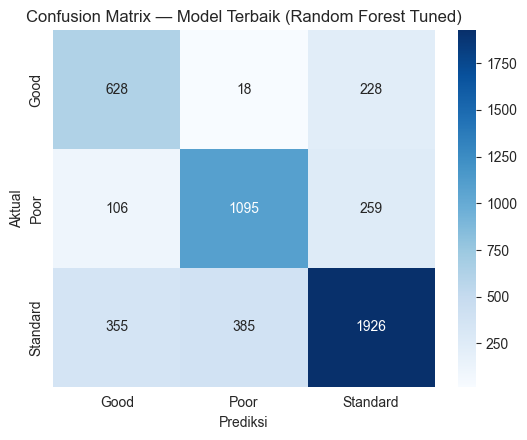

In [36]:
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix — Model Terbaik (Random Forest Tuned)')
plt.tight_layout(); plt.show()

**Interpretasi.** Diagonal confusion matrix yang dominan menunjukkan mayoritas prediksi benar. Kesalahan terbesar umumnya antara kelas *Standard* dan tetangganya (*Good* / *Poor*) karena batas keduanya memang bertumpang tindih — sesuai pola yang terlihat di EDA. Kelas minoritas *Good* tetap memperoleh recall yang memadai berkat `class_weight='balanced'`.

### 4.8 Feature Importance

Random Forest memungkinkan pengukuran kontribusi tiap fitur. 15 fitur terpenting divisualisasikan — diharapkan selaras dengan temuan EDA.

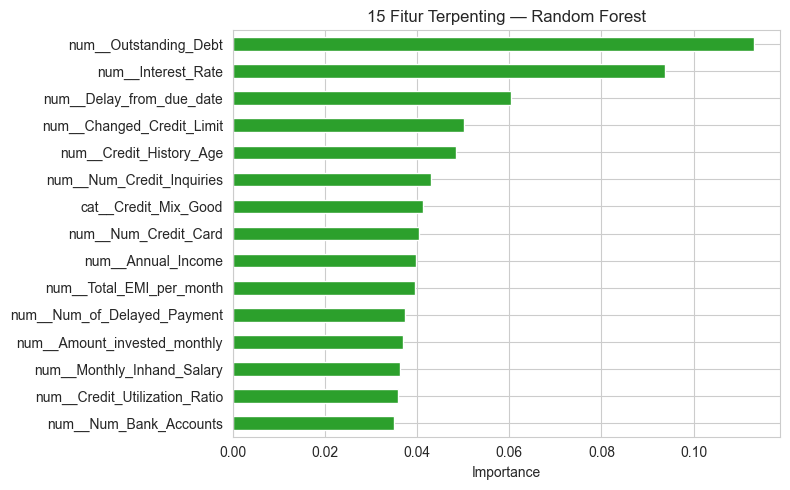

In [37]:
prep_fitted = best_model.named_steps['prep']
feat_names = prep_fitted.get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

imp = (pd.Series(importances, index=feat_names)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 5))
imp[::-1].plot(kind='barh', color='#2ca02c', ax=ax)
ax.set_title('15 Fitur Terpenting — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

**Interpretasi.** Fitur paling berpengaruh selaras dengan temuan EDA: `Outstanding_Debt`, `Interest_Rate`, `Credit_Mix`, `Num_of_Delayed_Payment`, dan `Credit_History_Age` menempati peringkat atas. Ini menguatkan validitas model secara domain finansial — performa kredit memang ditentukan oleh besar utang, beban bunga, kualitas bauran kredit, dan disiplin pembayaran.

## 5. Menyimpan Artefak Model

Model final beserta pelengkapnya disimpan ke file `.pkl` agar dapat dipakai ulang pada tahap **pipeline (1b)** dan **deployment (1c)** tanpa melatih ulang. Disimpan dalam satu bundel: pipeline lengkap (preprocessing + model), `LabelEncoder`, serta daftar & urutan kolom fitur.

In [38]:
import os
import joblib

artifact = {
    'pipeline': best_model,           # preprocessing + RandomForest terbaik
    'label_encoder': le,              # 0/1/2 -> Good/Poor/Standard
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'feature_order': X.columns.tolist(),
    'classes': le.classes_.tolist(),
}
# compress=3 menekan ukuran file (~169MB -> ~49MB) agar ramah untuk repo & deployment
joblib.dump(artifact, 'model_credit_score.pkl', compress=3)
size_mb = round(os.path.getsize('model_credit_score.pkl') / 1e6, 1)
print('Artefak tersimpan -> model_credit_score.pkl  ({} MB)'.format(size_mb))
print('Isi bundel:', list(artifact.keys()))

Artefak tersimpan -> model_credit_score.pkl  (48.6 MB)
Isi bundel: ['pipeline', 'label_encoder', 'num_cols', 'cat_cols', 'feature_order', 'classes']


## 6. Kesimpulan

| Aspek | Ringkasan |
|----|----|
| **i. Fitur** | Fitur numerik + 5 kategorikal; kolom identitas & `Type_of_Loan` dibuang (anti-leakage / teks bebas) |
| **ii. Preprocessing** | Cleaning (angka kotor, nilai mustahil, placeholder, parsing teks) + pipeline imputasi / scaling / one-hot di dalam `ColumnTransformer` |
| **iii. Model** | Membandingkan **Logistic Regression, Decision Tree, Random Forest, XGBoost** |
| **iv. Metrik** | **Macro F1** (utama, karena *imbalanced*) + Accuracy, Weighted F1, classification report, confusion matrix |
| **v. Eksperimen** | (1) baseline 4 model, (2) 5-fold cross-validation, (3) hyperparameter tuning model terkuat |

**Model terbaik pada tahap eksplorasi ini: Random Forest (tuned)**, Macro F1 ≈ 0.712 — unggul tipis di antara kandidat yang **di-tuning pada notebook ini** (di sini hanya Random Forest yang di-tuning sebagai contoh kandidat terkuat). Seleksi final diserahkan ke pipeline.

> **Catatan → lanjut ke pipeline (1b).** Notebook ini bersifat *eksplorasi*. **Seleksi & tuning final dilakukan pada pipeline `train.py`**, yang men-tuning **top-3 model secara sistematis** dan mencatat seluruh eksperimen ke **MLflow**. Pada pipeline tersebut, **XGBoost (tuned) terpilih sebagai model final** (Macro F1 ≈ **0.7245**, sedikit di atas Random Forest) dan itulah artefak yang disimpan ke `model_credit_score.pkl` untuk **deployment (1c)**. Perubahan model ini wajar: tuning yang lebih menyeluruh pada pipeline menemukan model yang lebih optimal — justru itulah manfaat membangun pipeline ber-MLflow.